<a href="https://colab.research.google.com/github/muajnstu/Multi-Class-Text-Classification-with-Transformers-and-LSTM/blob/main/Project_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install wordcloud matplotlib
from wordcloud import WordCloud

In [1]:
import numpy as np
import pandas as pd
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,  roc_auc_score
import matplotlib.pyplot as plt
from collections import Counter


In [2]:
def preprocess_data(csv_url, category_map):
    df = pd.read_csv(csv_url)
    df["Category"] = df["Category"].str.lower().str.strip().map(category_map)
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    df['processed_text'] = df['Title'].astype(str) + " " + df['Description'].astype(str)
    def extract_txt(text):
        match = re.search(r"(?<=\s\-\s).*", str(text))
        return match.group(0) if match else text
    df['processed_text'] = df['processed_text'].apply(extract_txt)
    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'https?://\S+|www\.\S+', '', text)
        text = re.sub(r'\[.*?\]', '', text)
        text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
        text = re.sub(r'\d', '', text)
        text = re.sub(r'\w*\d\w*', '', text)
        text = re.sub(r'\n', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    df['processed_text'] = df['processed_text'].apply(clean_text)
    df.rename(columns={'processed_text': 'text'}, inplace=True)
    X_train, X_temp, y_train, y_temp = train_test_split(df['text'], df['Category'], test_size=0.2, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
    return X_train, X_val, X_test, y_train, y_val, y_test

In [3]:

#9. Data Preparation

csv_url = "https://raw.githubusercontent.com/muajnstu/ML-Datasets/refs/heads/main/Youtube%20Video%20Dataset.csv"
category_map = {
    "travel blog": 0,
    "science&technology": 1,
    "food": 2,
    "art&music": 3,
    "manufacturing": 4,
    "history": 5
}
category_names = list(category_map.keys())
X_train, X_val, X_test, y_train, y_val, y_test = preprocess_data(csv_url, category_map)
print("Data loaded and preprocessed.")
summary = {}
summary_rocauc = {}

Data loaded and preprocessed.


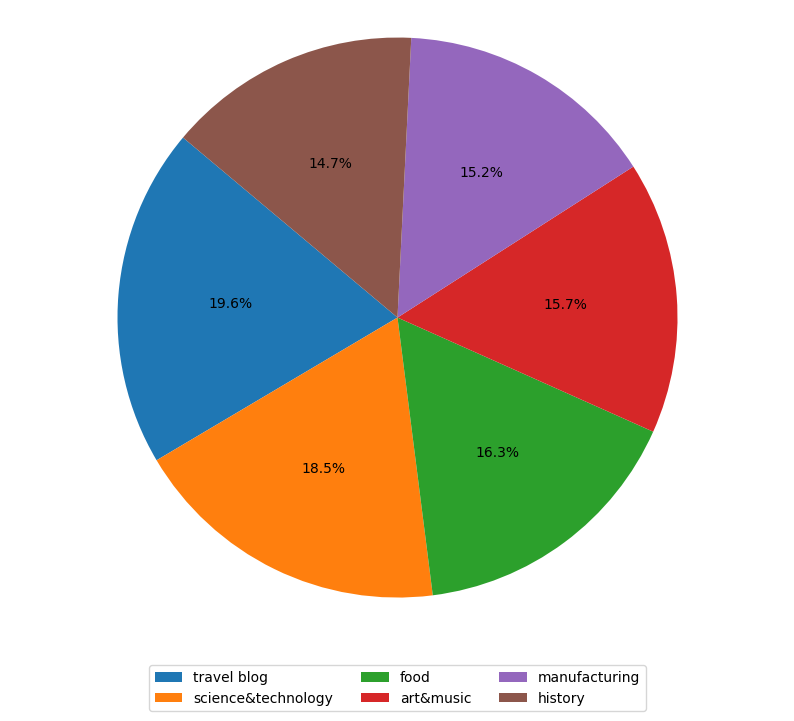

In [6]:
# Combine all datasets for plotting the overall distribution
y_all = pd.concat([y_train, y_val, y_test])

# Get the value counts of each category
category_counts = y_all.value_counts().sort_index()

# Convert category indices back to names
category_labels = [category_names[i] for i in category_counts.index]

# Create the pie chart
plt.figure(figsize=(10, 8))
plt.pie(category_counts, autopct='%1.1f%%', startangle=140)
plt.legend(category_labels, loc="lower center", bbox_to_anchor=(0.5, -0.15), ncol=3) # Legend at the bottom
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


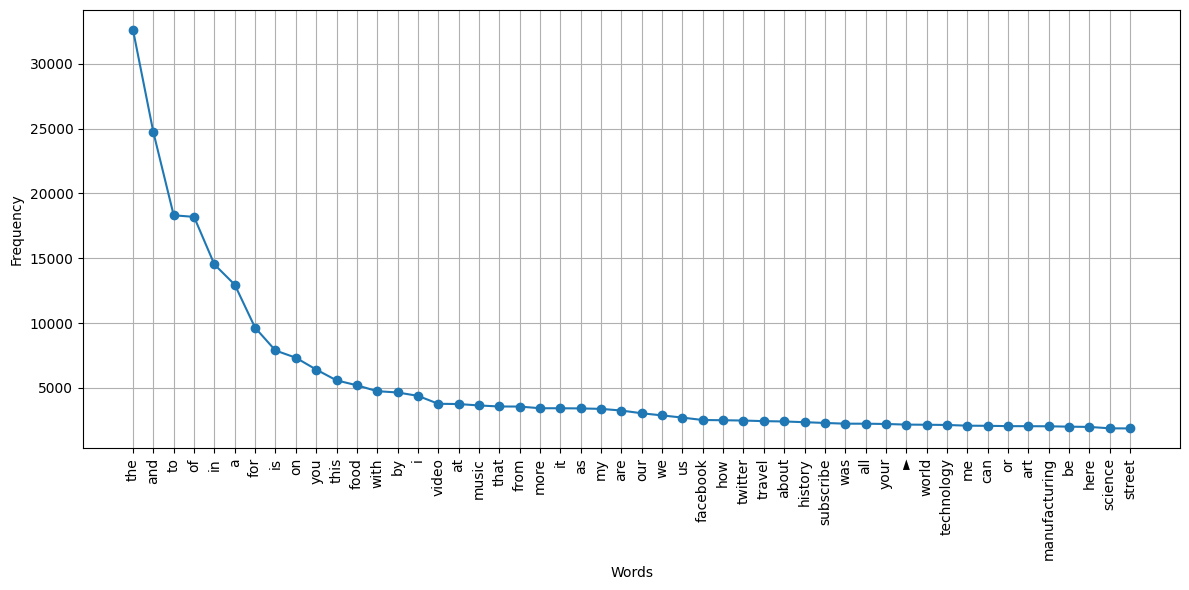

In [11]:
# Combine all processed text data
all_text = pd.concat([X_train, X_val, X_test])

# Tokenize and count words
all_words = ' '.join(all_text).split()
word_counts = Counter(all_words)

# Get the 50 most common words
most_common_words = word_counts.most_common(50)

# Separate words and counts for plotting
words, counts = zip(*most_common_words)

# Create the line graph
plt.figure(figsize=(12, 6))
plt.plot(words, counts, marker='o', linestyle='-')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

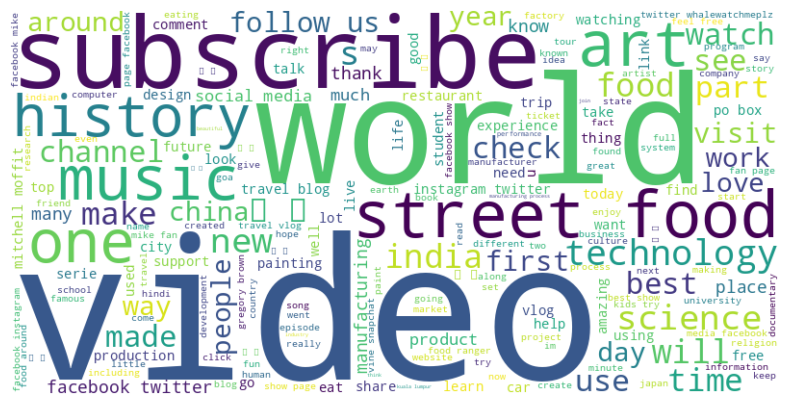

In [10]:
# Combine all processed text data into a single string
all_text_string = ' '.join(all_text)

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text_string)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()
